In [1]:
import numpy as np ; import matplotlib.pyplot as plt

def load_variables_to_dict(file_path):
    variables_dict = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if line.startswith('Variable'):
            parts = line.split(':')
            if len(parts) > 1:
                variable_info = parts[1].split('def =')
                if len(variable_info) > 1:
                    var_name = variable_info[0].split()[0].strip()
                    numerical_values = variable_info[1].split()
                    for value in numerical_values:
                        try:
                            num_value = float(value)
                            variables_dict[var_name.split(',')[0]] = num_value
                            break
                        except ValueError:
                            continue
    return variables_dict


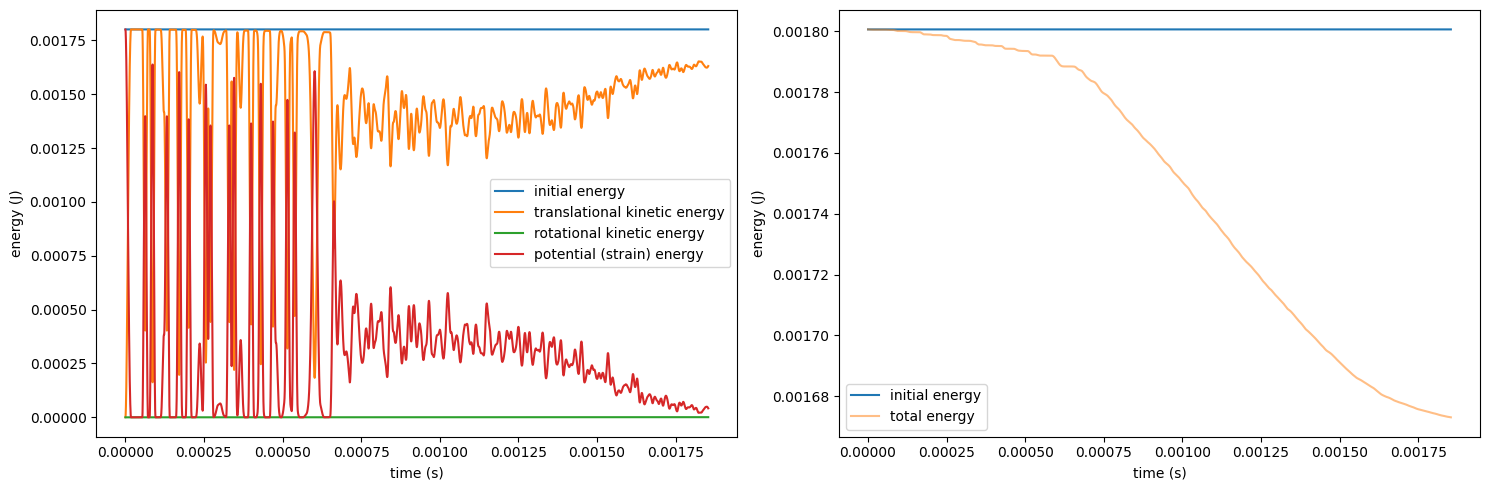

In [129]:

data = np.loadtxt('energy.dat', skiprows=1)
parameters = load_variables_to_dict('info')

time = data[:, 0].astype(int)*parameters['timeStep']
kin_eng = data[:, 1]
rotkin_eng = data[:, 2]
pot_eng = data[:, 3]
E0 = np.array([kin_eng[0] + pot_eng[0] + rotkin_eng[0]] * len(time))

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].set_xlabel('time (s)')
axs[0].set_ylabel('energy (J)')
axs[0].plot(time, E0, label='initial energy')
axs[0].plot(time, kin_eng, label='translational kinetic energy')
axs[0].plot(time, rotkin_eng, label='rotational kinetic energy')
axs[0].plot(time, pot_eng, label='potential (strain) energy')
axs[0].legend()
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('energy (J)')
axs[1].plot(time, E0, label='initial energy')
axs[1].plot(time, kin_eng + rotkin_eng + pot_eng, alpha=0.5, label='total energy')
axs[1].legend()
#axs[1].set_ylim(0.9999*E0[0], 1.0001*E0[0])
plt.tight_layout()
